In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Import necessary libraries
import os
import copy
from ipywidgets import interact, widgets
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pyFAI
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
from pyFAI.gui import jupyter
import pyFAI.io
from pyFAI.io import image
from pyFAI.io.image import read_image_data
from pyFAI.detectors import Detector, Pilatus1M
from pyFAI.calibrant import CALIBRANT_FACTORY
# from pyFAI.calibration import Calibrator
from pyFAI.geometryRefinement import GeometryRefinement
import fabio

In [4]:
from pyFAI.blob_detection import BlobDetection

In [5]:
from pyFAI.massif import Massif

In [6]:
from scipy.ndimage import gaussian_filter

In [7]:
from calibrator import *

## Integration

In [8]:
tif_path = '../AgBh/100225_doubling/test/0003_AgBh1000old_or_107.3.tif'
saxs_data = image.read_image_data(tif_path)
saxs_data

array([[-2,  2,  0, ..., 22, 28, -2],
       [ 1,  0,  0, ..., 25, 27, 26],
       [ 0,  0,  0, ..., 19, 36, 23],
       ...,
       [ 0,  1,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [-2,  0,  0, ...,  0,  0, -2]], dtype=int32)

In [9]:
saxs_data.shape

(1043, 981)

/tmp/ipykernel_28716/69016739.py:2: RuntimeWarning: divide by zero encountered in log1p
  im = ax.imshow(np.log1p(saxs_data), cmap='viridis', origin='lower')
/tmp/ipykernel_28716/69016739.py:2: RuntimeWarning: invalid value encountered in log1p
  im = ax.imshow(np.log1p(saxs_data), cmap='viridis', origin='lower')


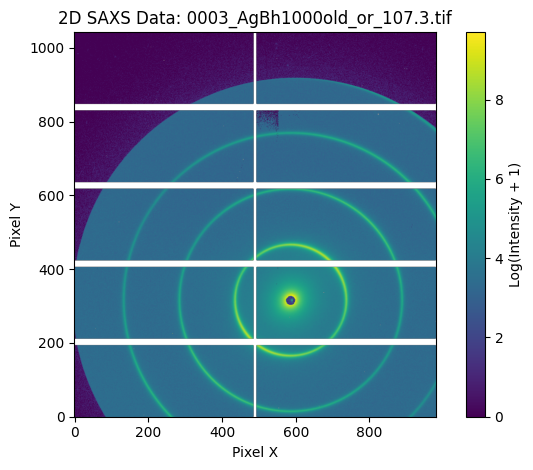

In [10]:
fig, ax = plt.subplots()
im = ax.imshow(np.log1p(saxs_data), cmap='viridis', origin='lower')
plt.colorbar(im, ax=ax, label='Log(Intensity + 1)')
ax.set_title(f"2D SAXS Data: {os.path.basename(tif_path)}")
ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

plt.tight_layout()
plt.show()

In [11]:
bd = BlobDetection(saxs_data)

In [12]:
bd.process()

After refinement : 0 keypoints
After refinement : 9 keypoints
After refinement : 2 keypoints
After refinement : 0 keypoints


After refinement : 0 keypoints


In [13]:
peaks = bd.peaks_from_area(mask=np.ones_like(saxs_data))
peaks

[(82.40610563755035, 778.1426870524883),
 (93.02642822265625, 789.9886474609375),
 (525.8572361022234, 370.53756311535835),
 (517.9241544380784, 362.99668175680563),
 (508.23829205334187, 354.9128185287118),
 (508.23829205334187, 354.9128185287118),
 (657.0711885765195, 289.35174295306206),
 (12.591512143611908, 922.1553177386522),
 (644.0282244831324, 275.6576960980892),
 (745.7832957059145, 182.9232505634427),
 (683.9496062994003, 127.92251968383789)]

In [14]:
massif = Massif(saxs_data)

In [15]:
# peaks = massif.peaks_from_area(np.ones_like(saxs_data))
# peaks

In [16]:
peaks = np.array(peaks, dtype=int)
peaks

array([[ 82, 778],
       [ 93, 789],
       [525, 370],
       [517, 362],
       [508, 354],
       [508, 354],
       [657, 289],
       [ 12, 922],
       [644, 275],
       [745, 182],
       [683, 127]])

In [17]:
def draw_peaks(data, peaks_, sigma=0.2):
    peaks_img = np.zeros_like(data, dtype=float)
    peaks_img[peaks_[:, 0], peaks_[:, 1]] = 1.
    peaks_img = gaussian_filter(peaks_img, sigma)
    peaks_img[peaks_img  > 0.] = 1.
    fig, ax = plt.subplots()
    im = ax.imshow(peaks_img, cmap='viridis', origin='lower')
    plt.colorbar(im, ax=ax, label='Peak proba')
    ax.set_title(f"Peaks: {os.path.basename(tif_path)}")
    ax.set_xlabel("Pixel X")
    ax.set_ylabel("Pixel Y")
    
    plt.tight_layout()
    plt.show()

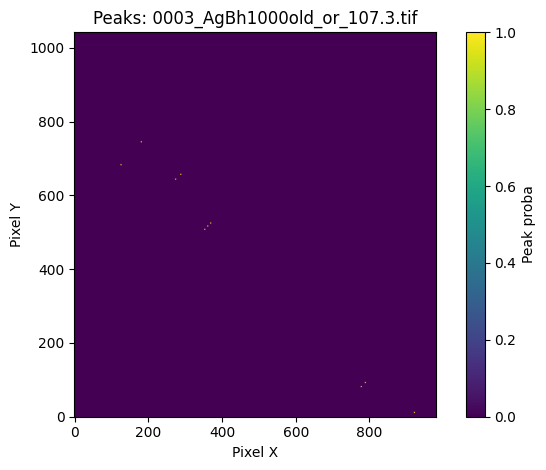

In [18]:
draw_peaks(saxs_data, peaks)

In [19]:
massif = Massif(saxs_data)

In [20]:
# iterations = 5
# first_order_peaks = peaks
# for i in range(iterations):
#     second_order_peaks = {}
#     new_edge_peaks = {}
#     for p in first_order_peaks:
#         new_peaks = massif.find_peaks(p)
#         second_order_peaks.extend(massif.find_peaks(p))
# second_order_peaks

In [21]:
# second_order_peaks = np.array(second_order_peaks, dtype=int)
# second_order_peaks.shape

In [22]:
# draw_peaks(saxs_data, second_order_peaks)

q0: 84.0
q1: 1279.0899999999674


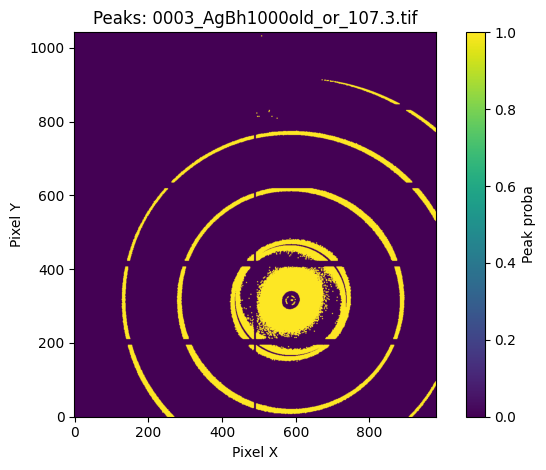

In [23]:
q0 = np.quantile(saxs_data, 0.925)
q1 = np.quantile(saxs_data, 0.995)
idx = np.where((saxs_data > q0) & (saxs_data < q1))
# idx = np.where(saxs_data > q0)
ring_pixels = np.transpose(np.vstack(idx))
print(f'q0: {q0}\nq1: {q1}')
draw_peaks(saxs_data, ring_pixels)

### Custom center detection

In [24]:
# def get_center(data, q_start=0.95, q_stop=0.995):
#     q0 = np.quantile(data, q_start)
#     q1 = np.quantile(data, q_stop)
#     idx = np.where((data > q0) & (data < q1))
#     ring_pixels = np.transpose(np.vstack(idx))
#     return np.sum(ring_pixels * data[idx].reshape(-1, 1), axis=0) / np.sum(data[idx])

In [25]:
# center = get_center(saxs_data, q_start=0.99)
# center = np.array(center, dtype=int)
# center

In [26]:
# draw_peaks(saxs_data, np.expand_dims(center, 0), sigma=0.9)

### Robust center estimation

In [27]:
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist

In [28]:
# def fit_circle(points):
#     x = points[:, 0]
#     y = points[:, 1]
#     n = len(x)
    
#     # Вычисление сумм
#     sum_x = np.sum(x)
#     sum_y = np.sum(y)
#     sum_x2 = np.sum(x**2)
#     sum_y2 = np.sum(y**2)
#     sum_xy = np.sum(x * y)
#     sum_x3 = np.sum(x**3)
#     sum_y3 = np.sum(y**3)
#     sum_x2y = np.sum(x**2 * y)
#     sum_xy2 = np.sum(x * y**2)
#     sum_x2_y2 = sum_x2 + sum_y2
    
#     # Матрица системы
#     A = np.array([
#         [sum_x2, sum_xy, sum_x],
#         [sum_xy, sum_y2, sum_y],
#         [sum_x,  sum_y,  n]
#     ])
    
#     # Вектор правой части
#     B = np.array([
#         -(sum_x3 + sum_xy2),
#         -(sum_y3 + sum_x2y),
#         -sum_x2_y2
#     ])
    
#     # Решение системы
#     c, d, e = np.linalg.solve(A, B)
    
#     # Параметры окружности
#     a = -c / 2
#     b = -d / 2
#     r = np.sqrt(a**2 + b**2 - e)
    
#     return (a, b, r)

In [29]:
# def get_center(data, q_start=0.95, q_stop=0.995, min_segment_len=50):
#     q0 = np.quantile(data, q_start)
#     q1 = np.quantile(data, q_stop)
#     idx = np.where((data > q0) & (data < q1))
#     ring_pixels = np.transpose(np.vstack(idx))

#     dbscan = DBSCAN(min_samples=10, eps=30.)
#     cluster = dbscan.fit_predict(ring_pixels)

#     ring_pixels = np.hstack([ring_pixels, cluster.reshape(-1, 1)])
#     # plot_df = pd.DataFrame(data=ring_pixels, columns=['y', 'x', 'cluster'])
    
#     # fig, ax = plt.subplots(figsize=(12, 12))
#     # sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster', ax=ax)

#     centers = []
#     for c in np.unique(cluster):
#         if c == -1:
#             continue
#         ring = ring_pixels[ring_pixels[:, 2] == c][:, [0, 1]]
#         if len(ring) < min_segment_len:
#             continue
#         center_x, center_y, _ = fit_circle(ring)
#         centers.append((center_x, center_y))

#     center = np.median(centers, axis=0)

#     return center

In [30]:
a, b = find_center(saxs_data)
a, b

(316.0504586993637, 586.8573407967461)

### Ring detection

In [32]:
# def find_local_maxima(arr, left_neighbors=1, right_neighbors=1):
#     if left_neighbors < 0 or right_neighbors < 0:
#         raise ValueError("Number of neighbors must be non-negative")
    
#     n = len(arr)
#     if n == 0:
#         return np.array([], dtype=int)
    
#     window_size = left_neighbors + right_neighbors + 1
#     if window_size > n:
#         return np.array([], dtype=int)
    
#     # Create sliding window view
#     windows = np.lib.stride_tricks.sliding_window_view(arr, window_size)
    
#     # The center position is at index left_neighbors in each window
#     center = left_neighbors
#     centers = windows[:, center]
    
#     # Compare with all other elements in the window
#     is_max = np.all(centers[:, None] >= np.delete(windows, center, axis=1), axis=1)
    
#     # Get the original indices (shifted by left_neighbors)
#     return np.where(is_max)[0] + left_neighbors

In [33]:
# def get_rings(data, q_start=0.95, q_stop=0.995, min_segment_len=50,
#               r_max=700, r_step=3, peak_width=60, I_threshold=80.):
#     """
#     Rings detection algorithm
#     How it works?

#     1. Finds the beam center 
#     2. Does primitive azimutal integration (I(r) = sum(I_i * max(threshold - |r - r_i|, 0)))
#     4. Finds the ring radii from auxilary 1d profile
#     5. For each radius r_j highlights all the points which satisfy (|r_j - r_i| < threshold && I > I_threshold (small) && I < qstop)
    
#     """

#     # delete invalid pixels
#     data = copy.deepcopy(data)
#     data[data > np.quantile(data, q_stop)] = 0
    
#     # find center
#     center = get_center_robust(data, q_start=q_start, q_stop=q_stop, min_segment_len=min_segment_len).reshape(1, -1)
    
#     # integrate and identify radii of rings
#     rs = np.arange(0, r_max + 1, r_step).reshape(-1, 1)
#     pixel_coords = np.fromfunction(
#                       lambda i, j: (i // data.shape[1]) * (j == 0) + (i % data.shape[1]) * (j == 1),
#                       (data.shape[0] * data.shape[1], 2),
#                       dtype=int
#                   )
    
#     r_i = cdist(center, pixel_coords)
#     I_i = (data[pixel_coords[:, 0], pixel_coords[:, 1]]).reshape(-1, 1)
#     integrated = np.maximum(10. - np.abs(rs - r_i), 0) @ I_i / (rs + 10.)

#     integrated = integrated.flatten()

#     fig, ax = plt.subplots()
#     ax.plot(rs, integrated)
#     ax.set_xlabel('pixel dim')
#     ax.set_ylabel('integrated intensity')

#     idx_rings = find_local_maxima(integrated, peak_width // r_step, peak_width // r_step)
#     r_rings = rs[idx_rings]

#     # TODO: two main problems
#     # 1. First peak - bright ring around the beam center, probably useless info
#     # 2. False peaks - some local maxima are possible which are not actually peaks
#     # simpler algorithm may be useful - to ignore the first peak and to peak pre-determined number of peaks

#     # identify all the bright pixels on the rings
#     # TODO implement a dynamic threshold which whould depend on the radius of the largest ring
#     # TODO maybe I could throw away the threshold
#     rings = []
#     for i, r in enumerate(r_rings):
#         ring = pixel_coords[(10. - np.abs(r - r_i) > 0.).flatten() & (I_i > I_threshold).flatten()]
#         rings.append(np.hstack([ring, np.full((len(ring), 1), i)])) 
#     rings = np.vstack(rings)

#     fig, ax = plt.subplots()
#     plot_df = pd.DataFrame(data=rings, columns=['y', 'x', 'ring_number'])
#     sns.scatterplot(data=plot_df, x='x', y='y', hue='ring_number', ax=ax)
    
#     return rings, r_rings, (rs, integrated)

In [36]:
bh_rings, rs_pixels, plot_data = get_rings(saxs_data, np.array([a, b]))

Text(0, 0.5, 'integrated intensity')

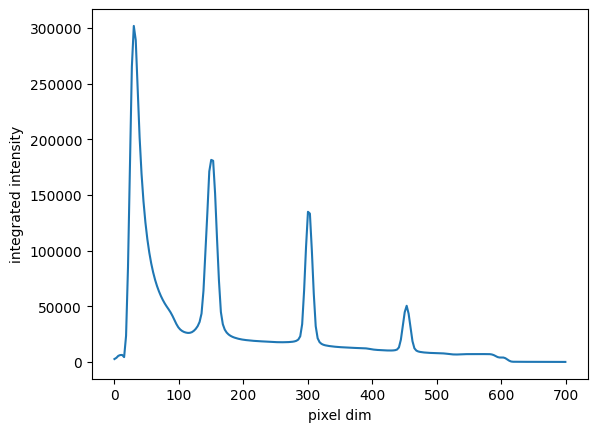

In [37]:
fig, ax = plt.subplots()
ax.plot(*plot_data)
ax.set_xlabel('pixel dim')
ax.set_ylabel('integrated intensity')

In [38]:
plt.close(fig)

<Axes: xlabel='x', ylabel='y'>

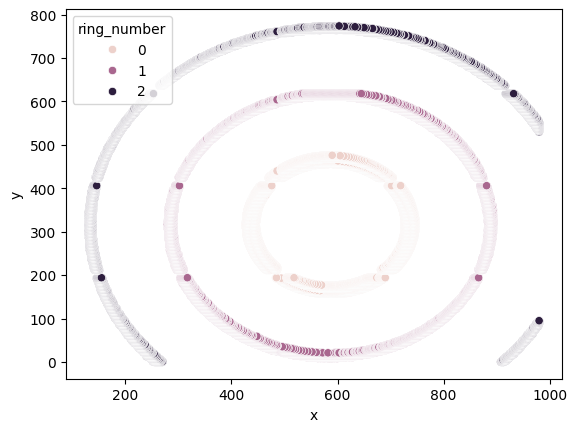

In [39]:
fig, ax = plt.subplots()
plot_df = pd.DataFrame(data=bh_rings, columns=['y', 'x', 'ring_number'])
sns.scatterplot(data=plot_df, x='x', y='y', hue='ring_number', ax=ax)

### Geometry refinement

In [49]:
pixel_size = 1.e-4
lmbd = 1.445e-10
detector = Pilatus1M(pixel_size, pixel_size)
gr = GeometryRefinement(bh_rings, 
                        calibrant=CALIBRANT_FACTORY('AgBh'),
                        dist=0.6, poni1=350*pixel_size, poni2=600*pixel_size,
                        detector = detector,
                        wavelength=lmbd
                       )

In [50]:
# gr.anneal()

In [51]:
gr.refine3(fix=['wavelength', 'rot3'])

5.071853666096013e-07

In [52]:
two_th = gr.calc_2th([0, 1, 2])
two_th

array([0.02475226, 0.04950831, 0.07427195])

In [53]:
s = 4 * np.pi * np.sin(two_th / 2) / lmbd * 1.e-9
s

array([1.07625648, 2.15251295, 3.22876943])

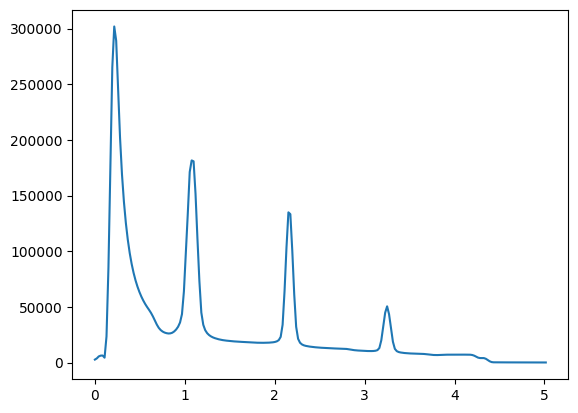

In [54]:
coef = s[0] / rs_pixels[0]
fig, ax = plt.subplots()
ax.plot(plot_data[0] * coef, plot_data[1])

In [55]:
gr

Detector Pilatus 1M	 PixelSize= 100µm, 100µm	 BottomRight (3)
Wavelength= 1.445000e-10 m
SampleDetDist= 6.085948e-01 m	PONI= 2.612200e-02, 4.731258e-02 m	rot1=-0.018726  rot2=0.009051  rot3=0.000000 rad
DirectBeamDist= 608.726 mm	Center: x=587.105, y=316.312 pix	Tilt= 1.192° tiltPlanRotation= 25.797° 𝛌= 1.445Å

In [56]:
refined_params = {
    'dist': gr._dist, 
    'poni1': gr._poni1, 'poni2': gr._poni2, 
    'rot1': gr._rot1, 'rot2': gr._rot2, 'rot3': gr._rot3 % (2 * np.pi)}
refined_params

{'dist': 0.6085948026549428,
 'poni1': 0.026122002069113196,
 'poni2': 0.04731258317097473,
 'rot1': -0.01872607804353361,
 'rot2': 0.00905053667306256,
 'rot3': 0.0}

In [57]:
ai = pyFAI.AzimuthalIntegrator(
    **refined_params,
    detector=detector,
    wavelength=lmbd
)

q_cal, I_cal = ai.integrate1d(saxs_data, npt=1000)

  File "/home/mikl/.conda/envs/saxs_analysis/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/mikl/.conda/envs/saxs_analysis/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/mikl/.conda/envs/saxs_analysis/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/mikl/.conda/envs/saxs_analysis/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/mikl/.conda/envs/saxs_analysis/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/mikl/.conda/envs/saxs_analysis/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/mikl/.conda/envs/saxs_analysis/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
    self._run

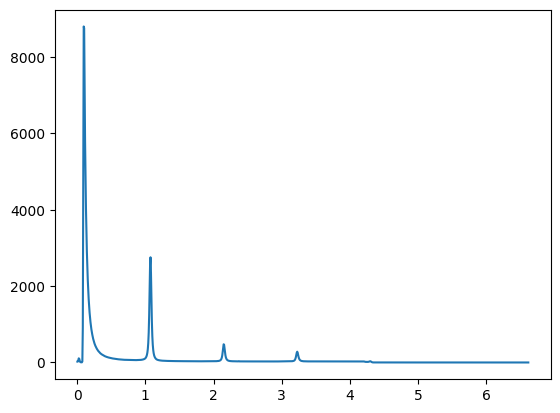

In [58]:
fig, ax = plt.subplots()
ax.plot(q_cal, I_cal)